# EDA
- Imports
- Load Clean Data
- Statistical Analysis
- Data Visualization

In [1]:
# imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Load pre-cleaned data
data = pd.read_csv(r"D:\ML_Project\Customer_churn_predection\Data\cleaned_data.csv")
data.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,NaN,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,NaN,No
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,NaN,53.85,NaN,Yes
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,NaN,42.30,1840.75,No
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,NaN,70.70,151.65,Yes


In [3]:
# data-backup and  info
df = data.copy()
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7053 entries, 0 to 7052
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7053 non-null   str    
 1   SeniorCitizen     7053 non-null   int64  
 2   Partner           7053 non-null   str    
 3   Dependents        7053 non-null   str    
 4   tenure            7053 non-null   int64  
 5   PhoneService      7053 non-null   str    
 6   MultipleLines     7048 non-null   str    
 7   InternetService   7050 non-null   str    
 8   OnlineSecurity    7053 non-null   str    
 9   OnlineBackup      7053 non-null   str    
 10  DeviceProtection  7053 non-null   str    
 11  TechSupport       7053 non-null   str    
 12  StreamingTV       7053 non-null   str    
 13  StreamingMovies   7053 non-null   str    
 14  Contract          7053 non-null   str    
 15  PaperlessBilling  7053 non-null   str    
 16  PaymentMethod     7050 non-null   str    
 17  Monthl

In [4]:
# statistical analysis
df.describe(include = 'all')

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
count,7053,7053.000000,7053,7053,7053.000000,7053,7048,7050,7053,7053,7053,7053,7053,7053,7053,7053,7050,7049.000000,7039.000000,7048
unique,2,NaN,2,2,NaN,2,3,3,3,3,3,3,3,3,3,2,4,NaN,NaN,2
top,Male,NaN,No,No,NaN,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,NaN,NaN,No
freq,3562,NaN,3645,4940,NaN,6369,3393,3097,3503,3089,3100,3478,2816,2789,3882,4177,2368,NaN,NaN,5176
mean,NaN,0.162059,NaN,NaN,32.366652,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,64.740750,2283.764874,NaN
std,NaN,0.368531,NaN,NaN,24.560025,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,30.086247,2266.743608,NaN
min,NaN,0.000000,NaN,NaN,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,18.250000,18.800000,NaN
25%,NaN,0.000000,NaN,NaN,9.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,35.500000,401.400000,NaN
50%,NaN,0.000000,NaN,NaN,29.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,70.300000,1398.250000,NaN
75%,NaN,0.000000,NaN,NaN,55.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,89.850000,3794.975000,NaN


In [13]:
# map 'SeniorCitizen' to categorical column

df["SeniorCitizen"] = df['SeniorCitizen'].map({
    0: 'No',
    1: 'Yes'
})
df.head(2)

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,No,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,NaN,No
1,Male,No,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,NaN,No


In [14]:
# Columns Details
all_columns = df.columns.to_list()
cat_columns = df.select_dtypes(include = 'object').columns.to_list()
num_columns = df.select_dtypes(include = 'number').columns.to_list()

cat_columns.remove('Churn')

print("All Columns: \n", all_columns)
print("\nCategorical Columns: \n", cat_columns)
print("\nNumeric Columns: \n", num_columns)

All Columns: 
 ['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']

Categorical Columns: 
 ['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']

Numeric Columns: 
 ['tenure', 'MonthlyCharges', 'TotalCharges']


C:\Users\LENOVO\AppData\Local\Temp\ipykernel_19612\3888361937.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_columns = df.select_dtypes(include = 'object').columns.to_list()


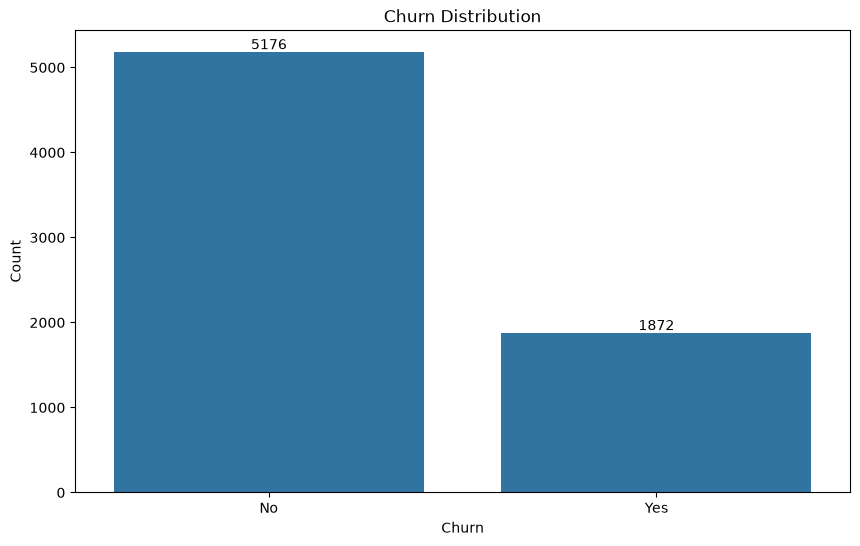

In [9]:
# target distribution
plt.figure(figsize = (10,6))
ax = sns.countplot(data = df, x = 'Churn')

for container in ax.containers:
    ax.bar_label(container)

plt.xlabel("Churn")
plt.ylabel("Count")
plt.title("Churn Distribution")
plt.show()

### Target Vs. Categorical features

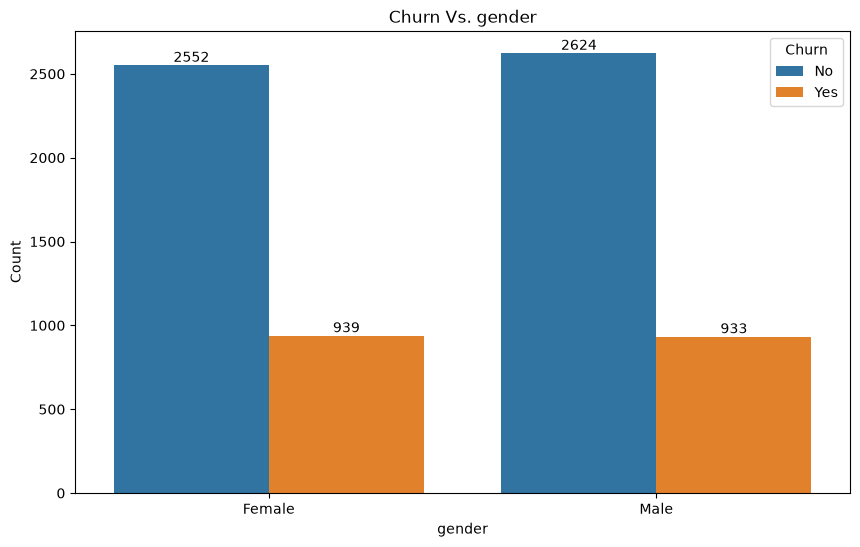

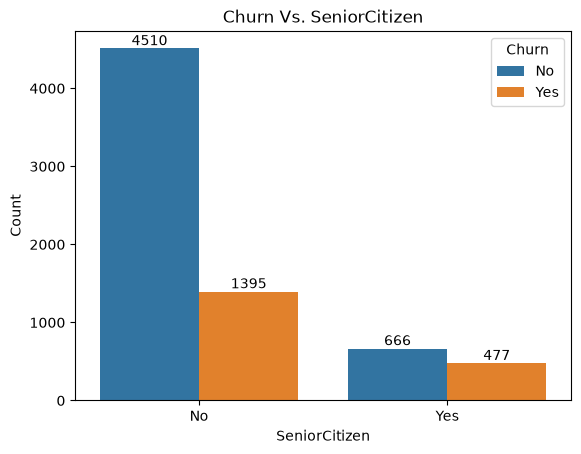

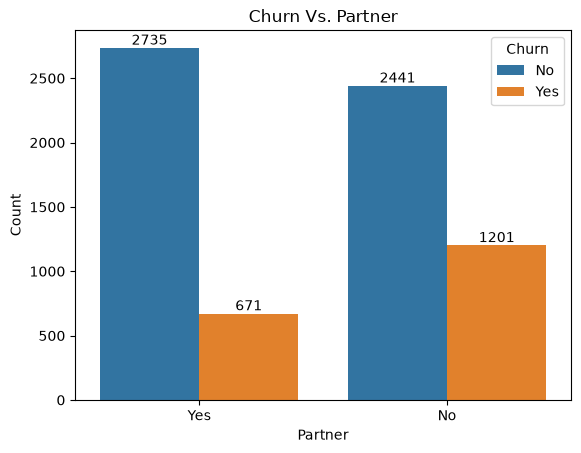

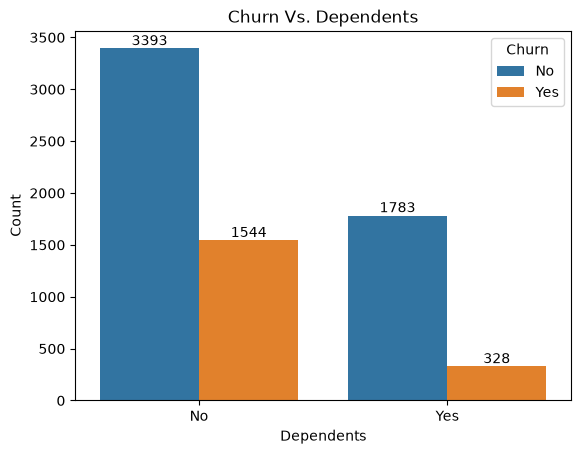

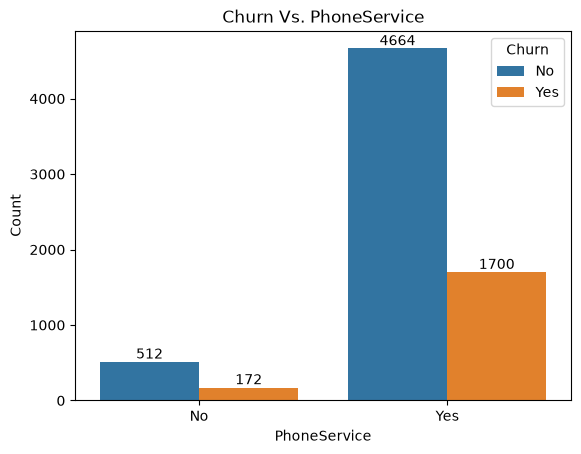

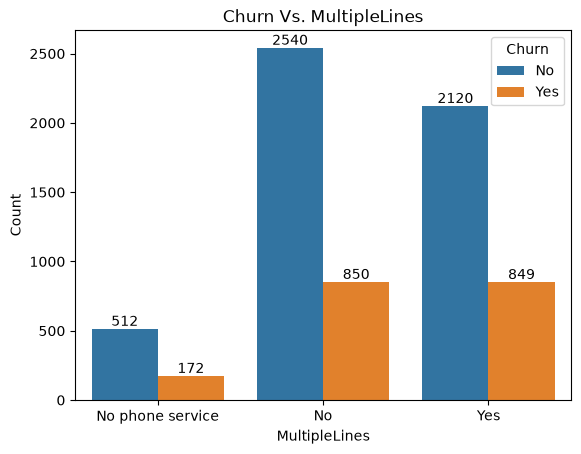

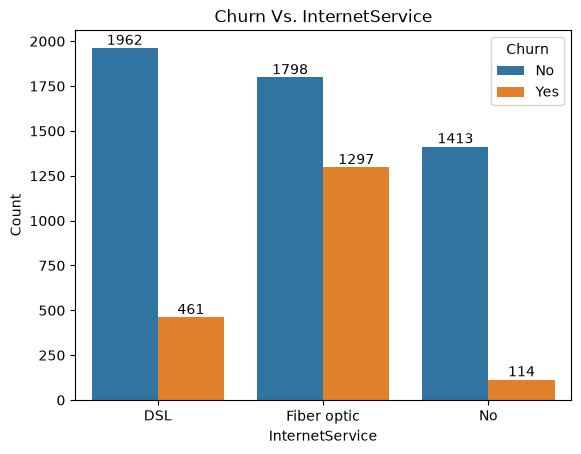

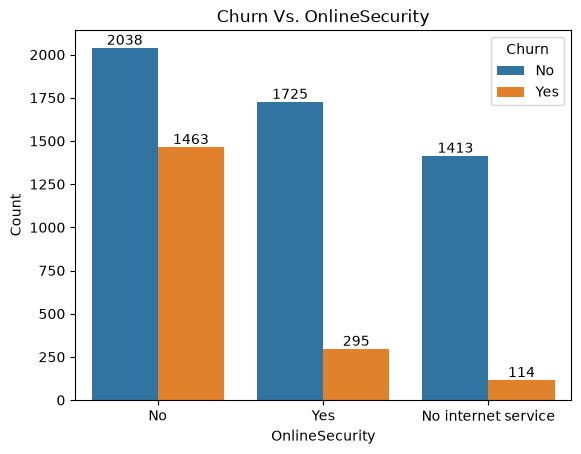

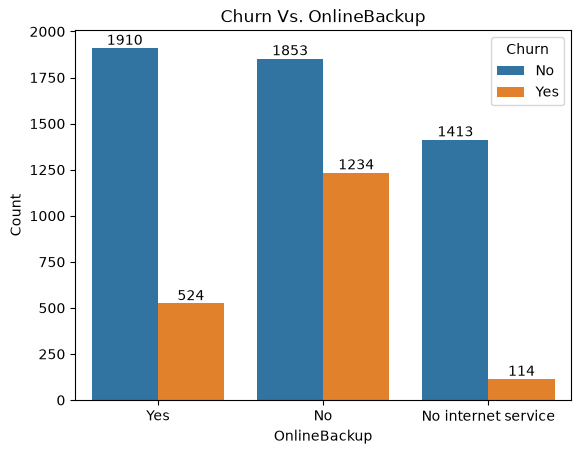

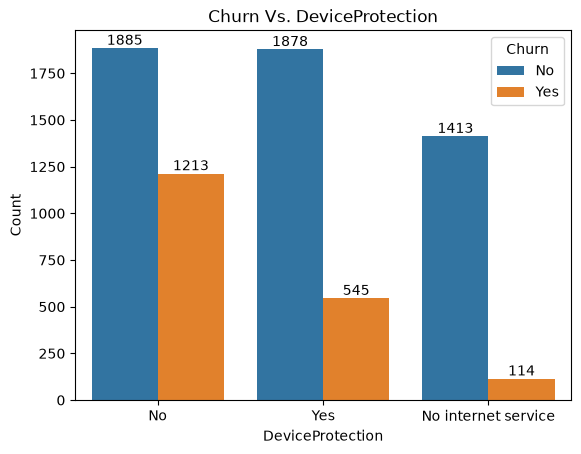

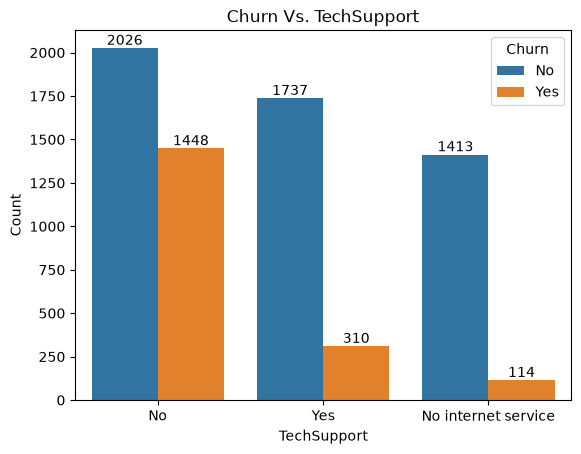

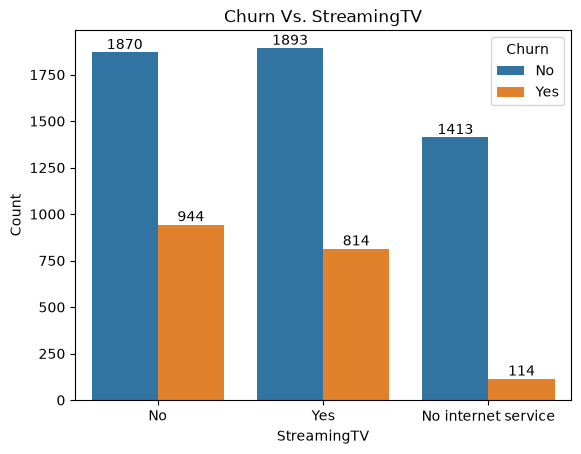

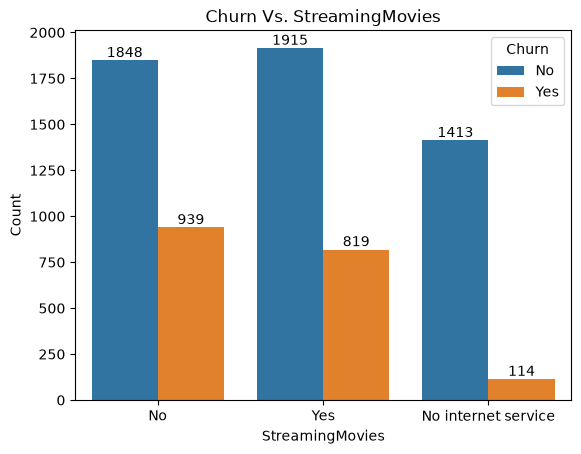

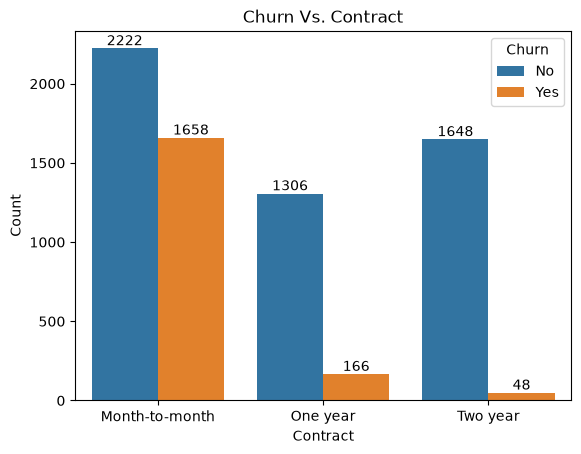

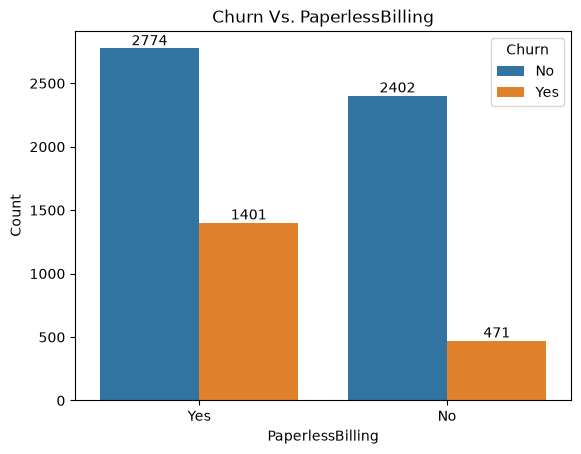

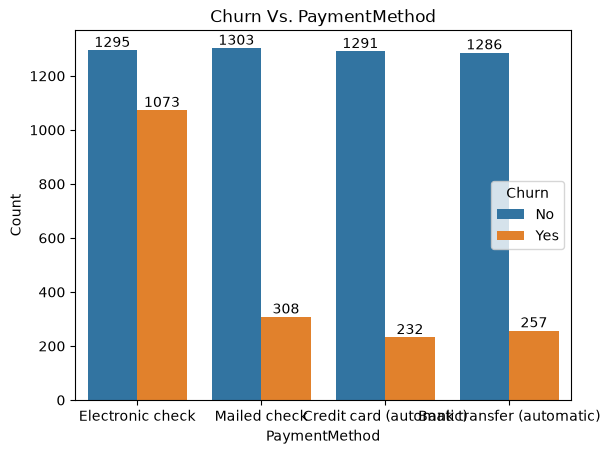

In [20]:
plt.figure(figsize = (10,6))
for column in cat_columns:
    ax = sns.countplot(data = df, x = column, hue = 'Churn')
    for container in ax.containers:
        ax.bar_label(container)
    plt.xlabel(f"{column}")
    plt.ylabel("Count")
    plt.title(f"Churn Vs. {column}")
    plt.show()

### target Vs. Numeric feature

In [15]:
df["Churn_Numeric"] = df['Churn'].map({
    'No': 0,
    'Yes': 1
})
df.head(2)


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,...,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,Churn_Numeric
0,Female,No,Yes,No,1,No,No phone service,DSL,No,Yes,...,No,No,No,Month-to-month,Yes,Electronic check,29.85,NaN,No,0.0
1,Male,No,No,No,34,Yes,No,DSL,Yes,No,...,No,No,No,One year,No,Mailed check,56.95,NaN,No,0.0


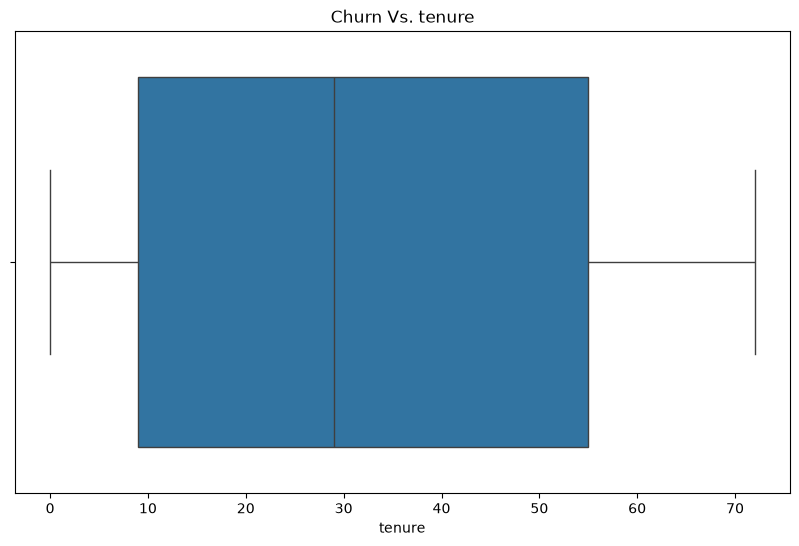

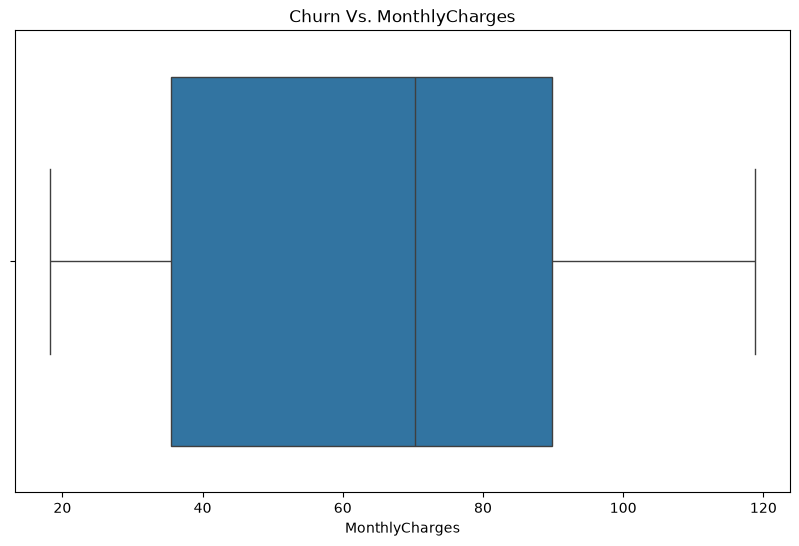

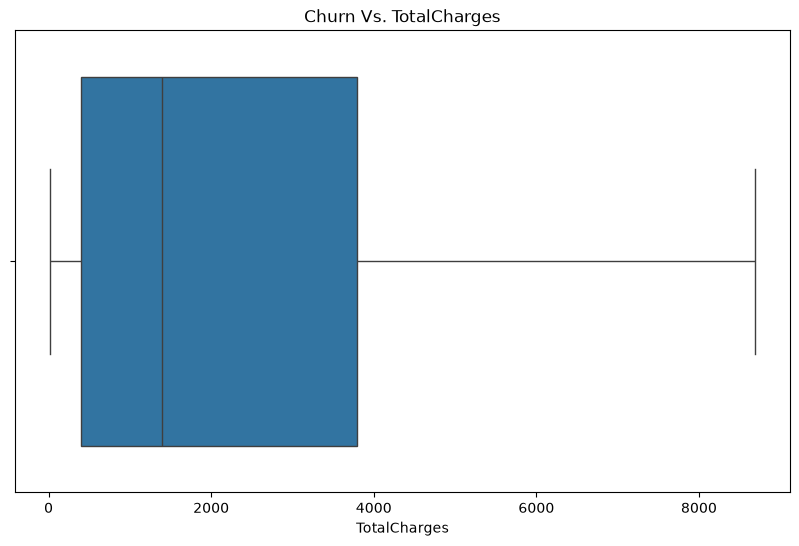

In [21]:
# visulazation for numeric column
for column in num_columns:
    plt.figure(figsize = (10,6))
    sns.boxplot(data = df, x = column)
    plt.xlabel(f"{column}")
    plt.title(f"Churn Vs. {column}")
    plt.show()

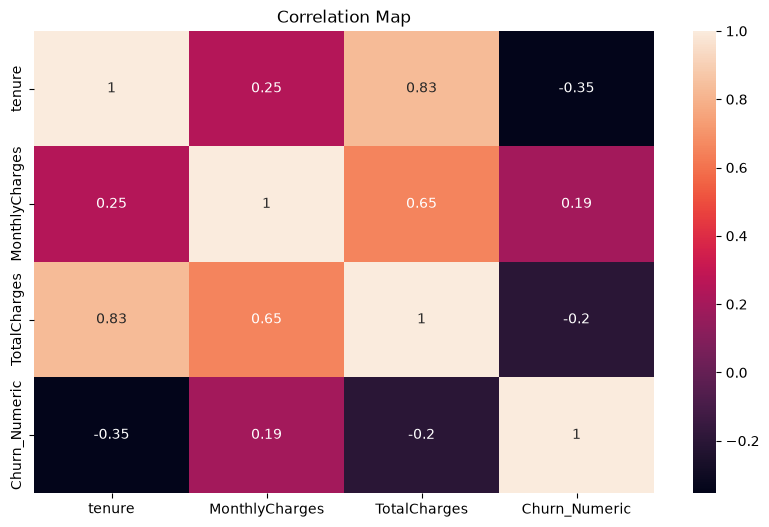

In [22]:
# correlation map
corr_data = df.select_dtypes(include = 'number').corr()
plt.figure(figsize = (10,6))
sns.heatmap(data = corr_data, annot = True)
plt.title('Correlation Map')
plt.show()